# Ejercicio 2: PyTorch
### Tarea: Construye una red neuronal convolucional (CNN) usando PyTorch para clasificar las imágenes del dataset MNIST.


## 1. Importación de librerías

Importamos las librerías específicas de **PyTorch** para este ejercicio:

- `torch`, `torch.nn`, `torch.optim`: núcleo de PyTorch para tensores, capas y optimizadores.
- `torchvision` y `torchvision.transforms`: descarga MNIST y aplica pipelines de preprocesado sobre las imágenes.
- `dataclasses`: para centralizar los hiperparámetros en una clase `Config`
- `DataLoader`, `random_split`: iteración por batches y separación de validación.
- `seaborn`: heatmaps para visualizar activaciones de capas fully connected.

Las librerías de propósito general (`numpy`, `matplotlib`, `sklearn.metrics`) se usan de la misma forma que en el Ejercicio 1.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import os
import random
from dataclasses import dataclass
from torch.utils.data import DataLoader, random_split
import seaborn as sns

## 2. Configuración de parámetros

Configuramos los parámetros necesarios para entrenar nuestro modelo. Esto incluye el número de épocas, la tasa de aprendizaje, el tamaño del lote (batch size) y la semilla aleatoria para reproducibilidad.

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


@dataclass
class Config:
    seed: int = 42
    batch_size: int = 128
    epochs: int = 25
    lr: float = 1e-3
    weight_decay: float = 0.0
    num_workers: int = 0
    val_split: int = 10_000
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    patience = 5  # nº de epochs sin mejora antes de parar


cfg = Config()
set_seed(cfg.seed)
print("Device:", cfg.device)


Device: cuda


## 3. Cálculo de media y desviación estándar de MNIST

A diferencia del Ejercicio 1 (donde dividíamos por 255 para llevar los píxeles a [0, 1]), aquí aplicamos una **normalización estadística**: restamos la media del dataset y dividimos por su desviación estándar. Esto centra la distribución alrededor de cero, lo que estabiliza el gradiente y acelera la convergencia.

Calculamos ambas estadísticas sobre el conjunto de entrenamiento antes de construir los dataloaders.

In [3]:
transform = transforms.ToTensor() # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                     transform=transform) 

loader = torch.utils.data.DataLoader(dataset, batch_size=1024, shuffle=False,
                                     num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

mean = 0.0
std = 0.0
total_pixels = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for images, _ in loader:
    images = images.to(device)

    mean += images.sum().item()
    std += (images ** 2).sum().item()
    total_pixels += images.numel()

mean = mean / total_pixels
std = (std / total_pixels - mean ** 2) ** 0.5

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: 0.13066047761878188
Std: 0.3081078047389192


## 4. Preparar Dataset y Dataloaders con Transformaciones Tensor y Normalización

Preparamos el dataset y los dataloaders para el entrenamiento y la evaluación del modelo. Aplicamos las transformaciones necesarias para convertir las imágenes a tensores de PyTorch y normalizarlas utilizando la media y desviación estándar calculadas previamente.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
    transforms.Normalize((mean,), (std,)) # Normaliza a media y desviación estándar calculadas
                                         # para centrar los datos alrededor de 0
])

train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  train = train + val
val_size = cfg.val_split
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 50000 | Val: 10000 | Test: 10000


## 5. Definición de la arquitectura CNN

A diferencia del MLP del Ejercicio 1, que aplana directamente los 784 píxeles en un vector, una **CNN** aprovecha la estructura espacial de la imagen: las capas convolucionales detectan patrones locales (bordes, curvas) que se combinan progresivamente en representaciones más abstractas.

Nuestra arquitectura sigue el patrón clásico: dos bloques **Conv --> ReLU --> MaxPool** para extracción de características, seguidos de capas **fully connected** para la clasificación final.

In [5]:
class CNN_MNIST(nn.Module):
    """
    CNN sencilla y efectiva para MNIST.
    Estructura:
        - Conv2d(1, 16, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Conv2d(16, 32, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Flatten -> Linear(32*7*7, 128) -> ReLU -> Linear(128, 10)
    """
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        # Capa Convolucional 1: entrada 1, salida 16, kernel 3x3
        # - Toma la imagen original (28x28) con pixeles en escala de grises (de ahí que solo necesitemos 1 canal)
        # extraemos 16 características simples p.ej: bordes, esquinas de la imagen original.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Primera función de activación: ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu1 = nn.ReLU()
        # Primera capa de pooling: MaxPool con kernel 2x2 y 2 pixeles de desplazamiento (stride)
        # - Reduce la dimensión espacial a la mitad (de 28x28 a 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa Convolucional 2: entrada 16, salida 32, kernel 3x3 
        # - Toma las 16 características extraídas en la capa anterior (14x14)
        # y extrae 32 nuevas características más complejas p.ej: combinaciones de bordes, formas, etc.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Segunda ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu2 = nn.ReLU()
        # Segunda capa de pooling
        # - Reduce la dimensión espacial a la mitad (de 14x14 a 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa lineal (Totalmente conectada)
        # Con 128 neuronas ocultas
        # La imagen original es 28x28. Tras dos maxpools de 2x2, queda de 7x7, y con 32 canales (características) 
        # en la última capa convolucional
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        # Con 128 neuronas ocultas y 10 neuronas de salida (para las 10 clases de dígitos)
        self.fc2 = nn.Linear(128, 10) # 10 clases de salida (dígitos 0-9)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Aplanar la salida convolucional, 
        # ya que la capa lineal espera un vector de características en lugar de una imagen 2D.
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

Imprimimos la arquitectura del modelo para verificar las dimensiones de cada capa.

In [6]:
model = CNN_MNIST()
model = model.to(cfg.device)
print(model)

CNN_MNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 6. Función de pérdida y optimizador

### Función de pérdida: CrossEntropyLoss

`nn.CrossEntropyLoss` combina internamente **softmax** (convierte los logits en probabilidades que suman 1) y **entropía cruzada** (penaliza cuanto menor sea la probabilidad asignada a la clase correcta). Es la función de pérdida estándar para clasificación multiclase en PyTorch, equivalente a lo que Scikit-learn aplica internamente en `MLPClassifier`.

In [7]:
criterion = nn.CrossEntropyLoss()

### Optimizador: Adam con scheduler

Usamos **Adam** (`lr=1e-3`, `weight_decay=0`) igual que en el Ejercicio 1.

In [ ]:
optimizer = optim.Adam(model.parameters(), 
                        lr=cfg.lr, # = 1e-3
                        weight_decay=cfg.weight_decay # = 0
                       )

> -"lr" (learning rate) es un multiplicador que indica qué tanto variarán los pesos al ajustarse en cada paso

> -"weight_decay" es un término de regularización que penaliza los pesos grandes, añadiendo un coste adicional a la función de pérdida. Esto 
> ayuda a evitar el sobreajuste y mejora la capacidad del modelo para generalizar a datos nuevos.

> En este caso, weight_decay = 0 implica que no se aplica regularización sobre los pesos del modelo. En este caso, la función de pérdida solo 
> depende del error de predicción, lo que puede facilitar el ajuste a los datos de entrenamiento pero aumentar el riesgo de sobreajuste, ya que
> no se penalizan los pesos grandes.

Como mejora adicional, añadimos **`ReduceLROnPlateau`**: si `val_acc` no mejora durante 2 epochs consecutivos, el learning rate se reduce a la mitad (`factor=0.5`). Esto permite afinar los pesos una vez que los gradientes son pequeños y un paso grande podría saltarse el mínimo.

In [ ]:
# Extra: Scheduler - Si en una epoch no mejora el val_acc, reduce el lr

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # queremos maximizar val_acc
    factor=0.5,      # nuevo_lr = lr * factor
    patience=2       # espera 2 epochs antes de reducir
)

> "mode" determina la medida usada para el early stopping. En este caso, 'max' significa que se quiere maximizar la metrica val_acc.  

> "factor" es el factor por el cual se reduce el learning rate. En este caso, se reduce la tasa de aprendizaje en un 50%.  

> "patience" es la cantidad de epochs que tienen que pasar antes de que se aplique la reduccion  

## 7. Entrenamiento

In [9]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


@torch.no_grad() # no se necesita gradiente para la evaluación
def evaluate(model: nn.Module, loader: DataLoader, device: str, preds_labels: bool = False):

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)

        if preds_labels:
            _, predicted = torch.max(logits, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches, all_preds, all_labels


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, device: str):
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True) # mover a la GPU
        labels = labels.to(device, non_blocking=True) # non_blocking: no bloquear el hilo

        optimizer.zero_grad(set_to_none=True) # limpiar gradiente: 0 = None
        logits = model(images) # El modelo toma un batch de imágenes y produce un batch de predicciones (logits)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

A diferencia del Ejercicio 1 (donde Scikit-learn abstrae todo en `.fit()`) o Keras (`model.fit`), en PyTorch controlamos explícitamente cada paso del bucle: forward pass, cálculo de pérdida, backward pass y actualización de pesos.

Incluimos **early stopping** (detener si `val_acc` no mejora en 5 epochs consecutivos) y guardamos el mejor checkpoint del modelo según `val_acc`.

In [ ]:
best_path = "best_mnist_model.pt"
epochs_without_improve = 0
best_val_acc = 0.0

for epoch in range(1, cfg.epochs + 1):
    # Entrenamiento
    model.train()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, cfg.device)

    # Validación
    model.eval()
    val_loss, val_acc, _, _  = evaluate(model, val_loader, cfg.device)


    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"Train loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} Val Acc: {val_acc:.4f}"
    )

    scheduler.step(val_acc) # reduce lr si no hay mejora en val_acc

    # Guardar mejor modelo por val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": cfg.__dict__,
            "val_acc": best_val_acc 
        }, best_path)
    else:
        epochs_without_improve += 1
    
    if epochs_without_improve >= cfg.patience:
        print("Early stopping activado")
        break

print("Mejor val_acc:", best_val_acc)
print("Guardado en:", best_path)

Epoch 01/25 | Train loss: 0.2504 Train Acc: 0.9270 | Val loss: 0.0944 Val Acc: 0.9729
Epoch 02/25 | Train loss: 0.0676 Train Acc: 0.9795 | Val loss: 0.0658 Val Acc: 0.9786
Epoch 03/25 | Train loss: 0.0467 Train Acc: 0.9857 | Val loss: 0.0493 Val Acc: 0.9848
Epoch 04/25 | Train loss: 0.0340 Train Acc: 0.9894 | Val loss: 0.0469 Val Acc: 0.9864
Epoch 05/25 | Train loss: 0.0275 Train Acc: 0.9910 | Val loss: 0.0496 Val Acc: 0.9852
Epoch 06/25 | Train loss: 0.0214 Train Acc: 0.9934 | Val loss: 0.0448 Val Acc: 0.9879
Epoch 07/25 | Train loss: 0.0173 Train Acc: 0.9945 | Val loss: 0.0428 Val Acc: 0.9874
Epoch 08/25 | Train loss: 0.0147 Train Acc: 0.9955 | Val loss: 0.0516 Val Acc: 0.9857
Epoch 09/25 | Train loss: 0.0117 Train Acc: 0.9961 | Val loss: 0.0398 Val Acc: 0.9883
Epoch 10/25 | Train loss: 0.0107 Train Acc: 0.9965 | Val loss: 0.0858 Val Acc: 0.9774
Epoch 11/25 | Train loss: 0.0086 Train Acc: 0.9974 | Val loss: 0.0549 Val Acc: 0.9866
Epoch 12/25 | Train loss: 0.0087 Train Acc: 0.9970 | V

## 8. Evaluación

Evaluamos el modelo sobre el conjunto de test, que no ha intervenido en ningún momento del entrenamiento ni en el criterio de early stopping.


Evaluando modelo...

Exactitud (Accuracy): 99.25%
Pérdida (Loss): 3.83%
Matriz de Confusión:


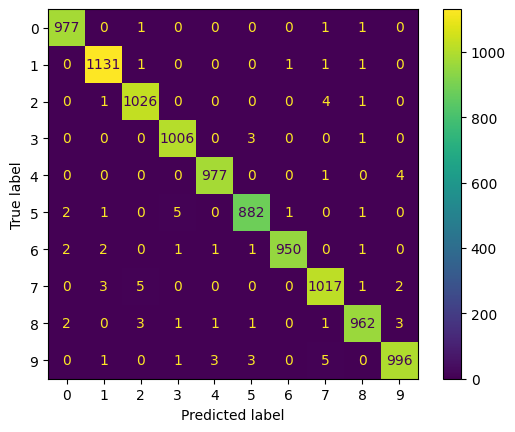

In [11]:
print("\nEvaluando modelo...")
model.eval()
all_preds = []
all_labels = []
test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, cfg.device, preds_labels = True)

print(f"\nExactitud (Accuracy): {test_acc * 100:.2f}%")
print(f"Pérdida (Loss): {test_loss * 100:.2f}%")
print("Matriz de Confusión:")
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds)

La CNN alcanza una accuracy de **~99.25 %** en el conjunto de prueba, superando claramente el techo del MLP del Ejercicio 1 (~97.9 %) al aprovechar la estructura espacial de las imágenes.

## 9. Visualización de características

Inspeccionamos las activaciones intermedias de la CNN para una imagen de test concreta. Esto permite entender qué patrones aprende cada etapa de la red, desde bordes simples en las primeras capas hasta formas abstractas en las últimas.

/home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/pytorch-mnist-features


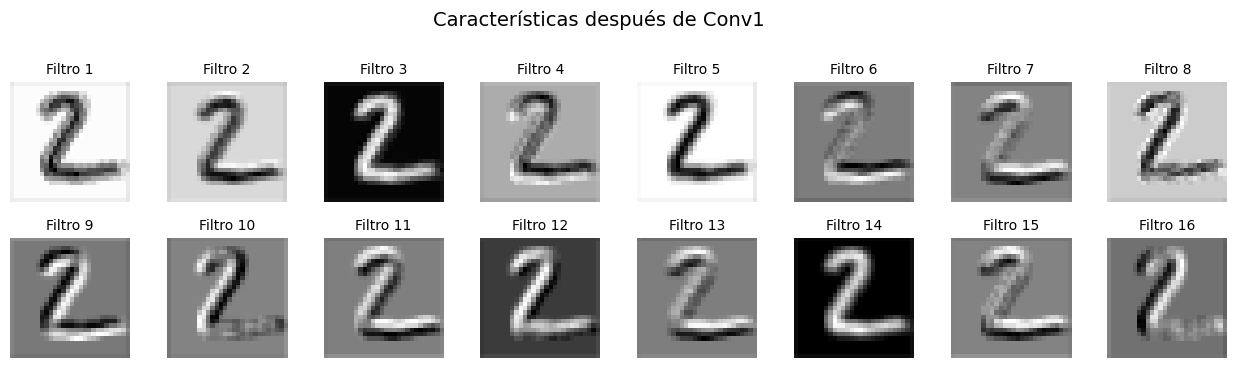


--> Cada filtro aprende patrones básicos sobre la imagen original: bordes horizontales, curvas simples, transiciones de intensidad. Los 16 mapas muestran la respuesta de cada filtro en cada posición de la imagen.



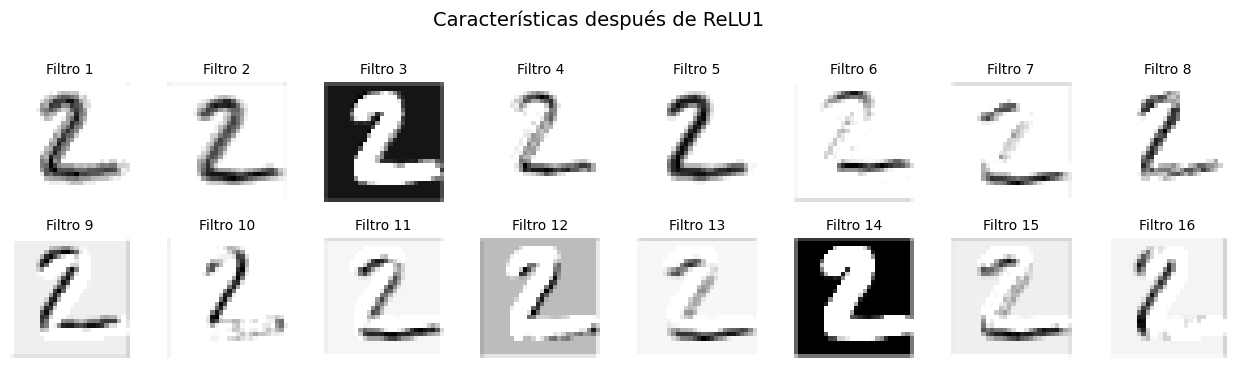


--> Se eliminan los valores negativos (se ponen a 0). Desaparecen las zonas que no aportan evidencia positiva del patrón que busca cada filtro: solo quedan activaciones positivas, lo que aumenta el contraste y centra la atención de la red en las zonas relevantes.



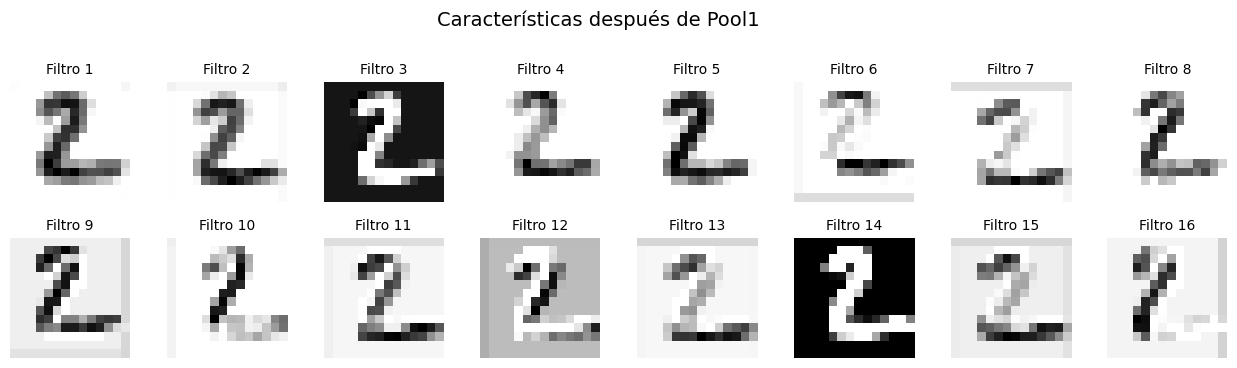


--> MaxPooling 2×2: se reduce la resolución de 28×28 a 14×14 conservando el valor máximo de cada región. Las imágenes son más comprimidas pero las zonas más activas se conservan. La red gana invarianza a pequeñas traslaciones.



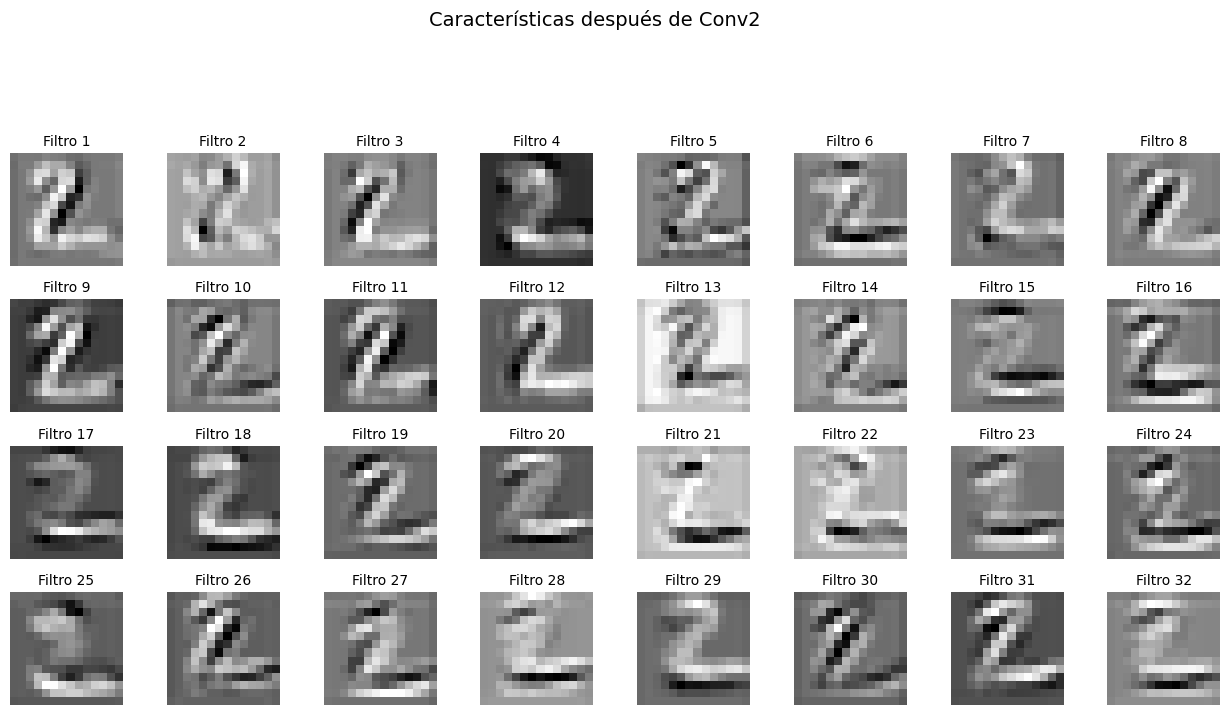


--> Los 32 filtros trabajan ahora sobre features ya procesadas, no píxeles crudos. Aprenden combinaciones de patrones básicos: formas curvas, bucles, estructuras más abstractas características de cada dígito.



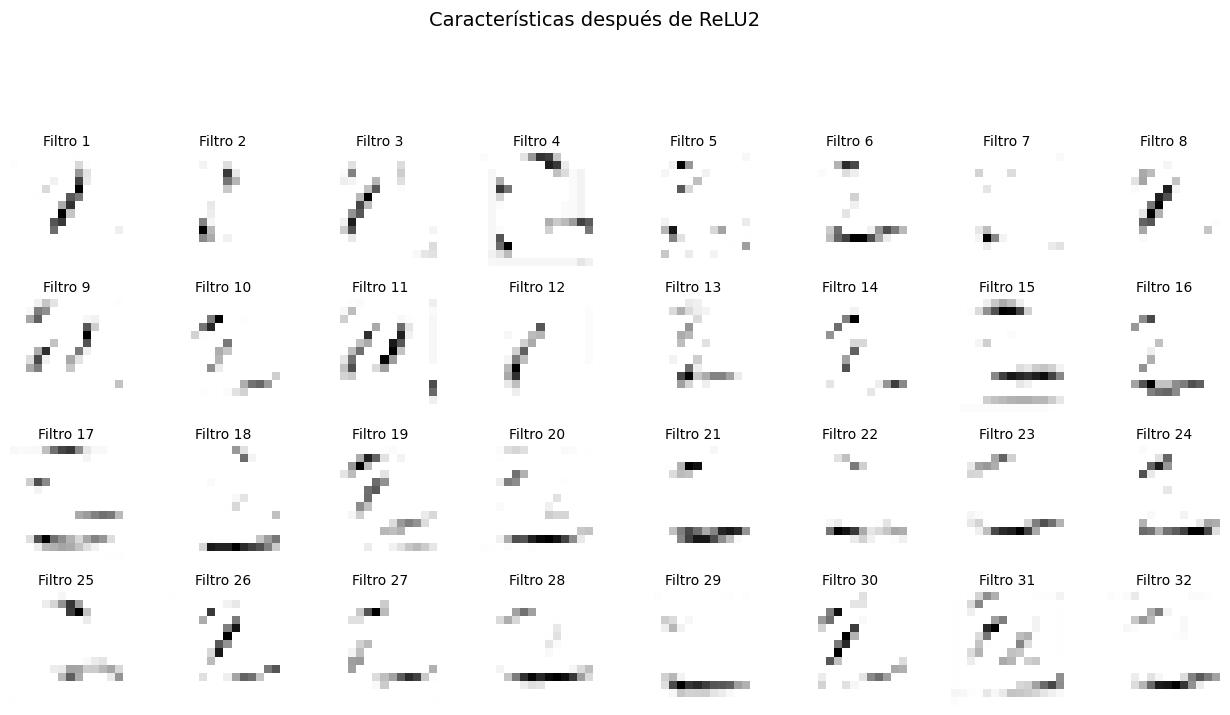


--> Segunda eliminación de negativos. Las activaciones son más definidas y selectivas: solo sobreviven las zonas donde la red detecta con confianza los patrones aprendidos en Conv2.



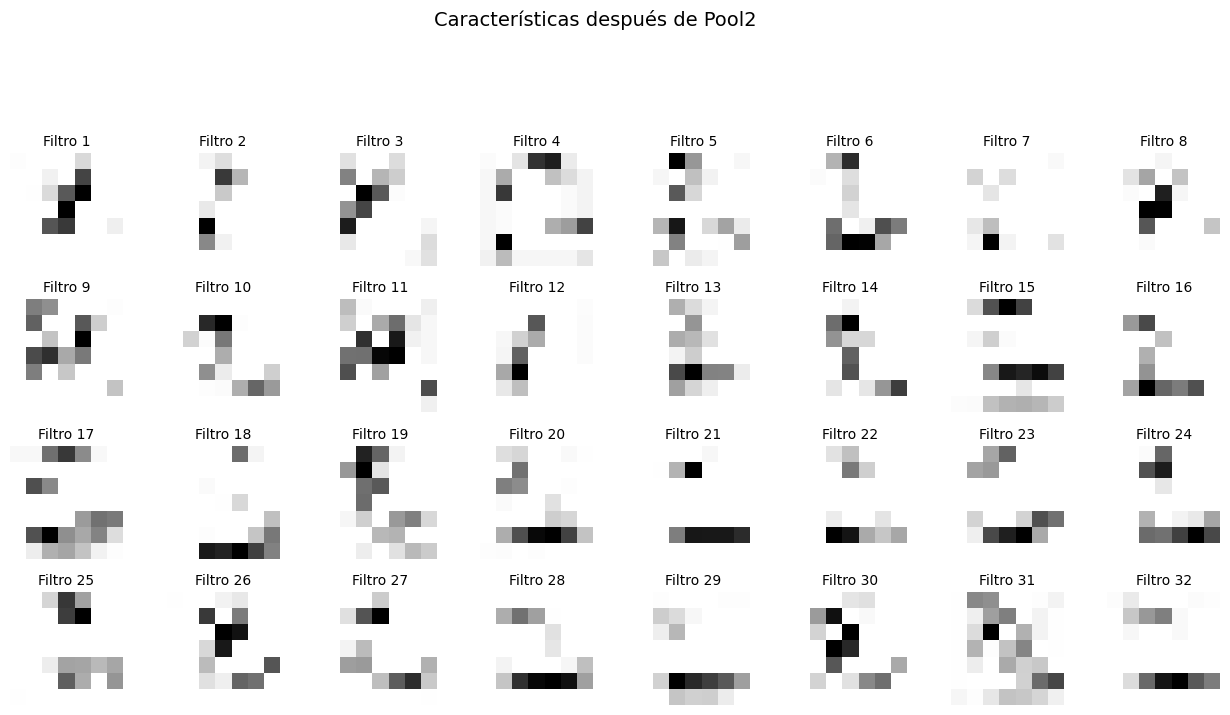


--> Segunda reducción espacial: de 14×14 a 7×7. La red tiene ahora una representación compacta: 32 mapas de 7×7 = 1568 valores que capturan los patrones más discriminativos para la clasificación.



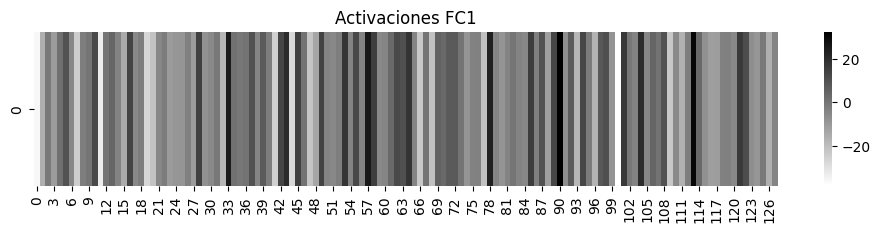


--> Se pasa de 32 mapas 2D de 7×7 a un vector de 128 neuronas. Ya no hay localidad espacial: cada neurona agrega información global de toda la imagen combinando todos los patrones detectados.



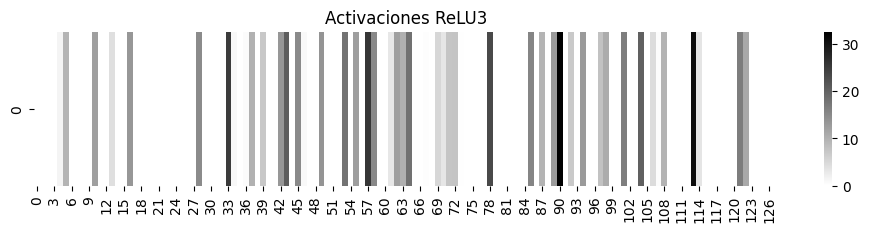


--> Igual que antes: se eliminan los negativos. Más ceros implica activaciones más selectivas: solo las combinaciones de patrones que el modelo considera relevantes para identificar el dígito permanecen activas.



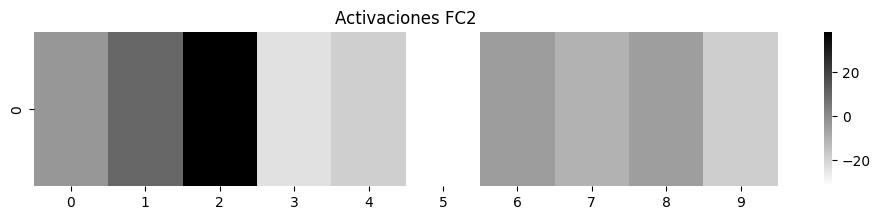


--> Capa de salida: las 128 activaciones se comprimen en 10 valores (logits), uno por dígito. Cuanto más oscuro el color, mayor el score para esa clase. Tras softmax, estos logits se convierten en probabilidades que suman 1: la clase con mayor valor es la predicción final.



In [13]:
__file__ = os.path.abspath("ejercicio_2_pytorch.ipynb")
current_dir = os.path.dirname(__file__)
img_dir = os.path.join(current_dir, "pytorch-mnist-features")

os.makedirs(img_dir, exist_ok=True)

print(img_dir)

def visualizar_caracteristicas(modelo, imagen_tensor):
    modelo.eval()
    imagen_tensor = imagen_tensor.to(cfg.device)

    with torch.no_grad():
        features = modelo.conv1(imagen_tensor.unsqueeze(0))
        plot_caracteristicas(features, title="Características después de Conv1",
            desc="Cada filtro aprende patrones básicos sobre la imagen original: bordes horizontales, curvas simples, transiciones de intensidad. Los 16 mapas muestran la respuesta de cada filtro en cada posición de la imagen.")

        features = modelo.relu1(features)
        plot_caracteristicas(features, title="Características después de ReLU1",
            desc="Se eliminan los valores negativos (se ponen a 0). Desaparecen las zonas que no aportan evidencia positiva del patrón que busca cada filtro: solo quedan activaciones positivas, lo que aumenta el contraste y centra la atención de la red en las zonas relevantes.")

        features = modelo.pool1(features)
        plot_caracteristicas(features, title="Características después de Pool1",
            desc="MaxPooling 2×2: se reduce la resolución de 28×28 a 14×14 conservando el valor máximo de cada región. Las imágenes son más comprimidas pero las zonas más activas se conservan. La red gana invarianza a pequeñas traslaciones.")

        features = modelo.conv2(features)
        plot_caracteristicas(features, title="Características después de Conv2",
            desc="Los 32 filtros trabajan ahora sobre features ya procesadas, no píxeles crudos. Aprenden combinaciones de patrones básicos: formas curvas, bucles, estructuras más abstractas características de cada dígito.")

        features = modelo.relu2(features)
        plot_caracteristicas(features, title="Características después de ReLU2",
            desc="Segunda eliminación de negativos. Las activaciones son más definidas y selectivas: solo sobreviven las zonas donde la red detecta con confianza los patrones aprendidos en Conv2.")

        features = modelo.pool2(features)
        plot_caracteristicas(features, title="Características después de Pool2",
            desc="Segunda reducción espacial: de 14×14 a 7×7. La red tiene ahora una representación compacta: 32 mapas de 7×7 = 1568 valores que capturan los patrones más discriminativos para la clasificación.")

        flattened = features.view(features.size(0), -1)
        features = modelo.fc1(flattened)
        plot_fc_features(features, "Activaciones FC1",
            desc="Se pasa de 32 mapas 2D de 7×7 a un vector de 128 neuronas. Ya no hay localidad espacial: cada neurona agrega información global de toda la imagen combinando todos los patrones detectados.")

        features = modelo.relu3(features)
        plot_fc_features(features, "Activaciones ReLU3",
            desc="Igual que antes: se eliminan los negativos. Más ceros implica activaciones más selectivas: solo las combinaciones de patrones que el modelo considera relevantes para identificar el dígito permanecen activas.")

        features = modelo.fc2(features)
        plot_fc_features(features, "Activaciones FC2",
            desc="Capa de salida: las 128 activaciones se comprimen en 10 valores (logits), uno por dígito. Cuanto más oscuro el color, mayor el score para esa clase. Tras softmax, estos logits se convierten en probabilidades que suman 1: la clase con mayor valor es la predicción final.")


def plot_caracteristicas(features, title, desc=""):
    features = features.squeeze(0)  # [canales, H, W]
    num_canales = features.shape[0]

    n_cols = 8
    n_rows = (num_canales + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))

    axes = axes.flatten()
    for i in range(num_canales):
        ax = axes[i]
        ax.imshow(features[i].cpu().numpy(), cmap='binary')
        ax.axis('off')
        ax.set_title(f"Filtro {i+1}", fontsize=10)

    plt.subplots_adjust(top=0.8, hspace=0.3, wspace=0.1)
    fig.suptitle(title, fontsize=14)
    filename = title.lower().strip().replace(" ", "_") + ".png"
    filepath = os.path.join(img_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.show()

    if desc:
        print(f"\n--> {desc}\n")


def plot_fc_features(features, title, desc=""):
    features = features.squeeze(0).cpu().numpy()
    plt.figure(figsize=(12, 2))
    sns.heatmap(features[np.newaxis, :], cmap='binary', cbar=True)
    plt.title(title)
    filename = title.lower().strip().replace(" ", "_") + ".png"
    filepath = os.path.join(img_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.show()

    if desc:
        print(f"\n--> {desc}\n")


sample_img, _ = test_ds[1]
visualizar_caracteristicas(model, sample_img)


## Conclusiones

La CNN de PyTorch alcanza ~99.1% de accuracy, mejorando significativamente el 97.9% del MLP del Ejercicio 1. La clave está en las capas convolucionales: en lugar de tratar cada píxel como independiente, aprenden filtros que detectan patrones locales (bordes, curvas) y los combinan jerárquicamente en representaciones cada vez más abstractas, como muestra la visualización de la Sección 9.

PyTorch exige bastante más código que Scikit-learn (bucle de entrenamiento manual, gestión explícita de gradientes y dispositivo, early stopping propio), pero a cambio ofrece control total sobre cada paso, lo que facilita la experimentación y la extensión a arquitecturas más complejas. El scheduler `ReduceLROnPlateau` y el guardado del mejor checkpoint son ejemplos de esa flexibilidad.